# 04 — Product encoding: chunked, compressed rasters

**Fix.** The DISP-CAL writer passes an explicit NetCDF encoding to every `to_netcdf`
call: raster layers are written in `(256, 256)` chunks (`(1, 256, 256)` for `(time, y, x)`),
gzip level 4 with the shuffle filter, `float32` with `_FillValue = NaN` — the same storage
layout as the DISP-S1 input. `output_options.compression` of the PGE runconfig (and
`cal-disp config --compression/--no-compression`) is honoured.

**Where the defect was** (commit `d0901b3`). `src/cal_disp/product/output/_cal.py` — the
four `to_netcdf` calls (main group ~l.312, identification ~l.502, metadata ~l.593,
auxiliary ~l.642) had no `encoding=`; `compression` in
`src/cal_disp/config/pge_runconfig.py:61` was never read by the writer. Result:
`/calibration` and `/calibration_std` stored contiguous and uncompressed (292.7 MB each).

**What is demonstrated.** The golden dataset on disk is produced by the *fixed* code, so
the "before" state is reconstructed here: the golden arrays are written to scratch with
the pre-fix writer taken from git history (`d0901b3`). Then:
1. h5py inspection of that pre-fix product and of the DISP-S1 input;
2. the same arrays written with the fixed writer (`compression=True` and `False`);
3. file size, chunking/filters, what a 512×512 window read costs, and that the arrays
   round-trip bit-identically.

In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks"; SCRATCH.mkdir(parents=True, exist_ok=True)

In [2]:
import shutil
import time

import h5py
import numpy as np
import pandas as pd
import xarray as xr

import cal_disp
from cal_disp.product import CalProduct, DispProduct

pd.set_option("display.width", 200)
DISP_NC = next((GOLDEN / "input_data" / "disp").glob("OPERA_L3_DISP-S1_*.nc"))
GOLDEN_NC = next((GOLDEN / "golden_output").glob("OPERA_L4_DISP-CAL-S1_*.nc"))
GOLDEN_PNG = GOLDEN_NC.with_suffix(".png")
print("cal_disp from:", Path(cal_disp.__path__[0]).relative_to(REPO) if Path(cal_disp.__path__[0]).is_relative_to(REPO) else cal_disp.__path__[0])
print("DISP input   :", DISP_NC.name)
print("golden output:", GOLDEN_NC.name)

/u/aurora-r0/govorcin/01_OPERA/VLM/DISP_CAL/gamma_release/cal-disp/.claude/worktrees/agent-ab3b9815b523f284b/.pixi/envs/dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cal_disp from: src/cal_disp
DISP input   : OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc
golden output: OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc


## 1. Before the fix: the pre-fix writer

`old_module` imports a module of commit `d0901b3` from git history; `before_product`
writes the golden arrays with that commit's `build_main_dataset` /
`build_auxiliary_dataset` and, as that code did, `to_netcdf` without an encoding.

In [3]:
import subprocess
import types

OLD_COMMIT = "d0901b3"  # gamma-release before the product fixes (d0548bf..79ab02a)


def old_module(rel_path: str) -> types.ModuleType:
    """Import one module of the pre-fix code straight from git history."""
    src = subprocess.check_output(["git", "-C", str(REPO), "show", f"{OLD_COMMIT}:{rel_path}"], text=True)
    mod = types.ModuleType("old_" + Path(rel_path).stem.strip("_"))
    mod.__file__ = f"{OLD_COMMIT}:{rel_path}"
    exec(compile(src, mod.__file__, "exec"), mod.__dict__)
    return mod

In [4]:
def golden_arrays():
    """Coordinates, layers and DISP spatial_ref of the golden product."""
    with xr.open_dataset(GOLDEN_NC, engine="h5netcdf") as ds:
        coords = {"time": ds.time.values, "y": ds.y.values, "x": ds.x.values}
        layers = {k: ds[k].values for k in ("calibration", "calibration_std")}
        extra = {k: ds.attrs[k] for k in ("gnss_reference_epoch", "auxiliary_model_3d_resolution", "calibration_resolution") if k in ds.attrs}
    with xr.open_dataset(GOLDEN_NC, group="auxiliary", engine="h5netcdf") as ds:
        aux_coords = {"time": ds.time.values, "y": ds.y.values, "x": ds.x.values}
        aux = {k: ds[k].values for k in ("north_south", "east_west", "up_down")}
    with xr.open_dataset(DISP_NC, engine="h5netcdf") as ds:
        spatial_ref = ds["spatial_ref"].load()
    return coords, layers, extra, aux_coords, aux, spatial_ref


def before_product(out_dir: Path = SCRATCH / "before_product") -> Path:
    """The golden arrays written by the pre-fix writer (reused from scratch if present).

    Uses build_main_dataset/build_auxiliary_dataset of commit d0901b3 and, as
    that code did, to_netcdf without any encoding.
    """
    path = out_dir / GOLDEN_NC.name
    if path.exists():
        return path
    out_dir.mkdir(parents=True, exist_ok=True)
    old_main = old_module("src/cal_disp/product/output/_main.py")
    old_aux = old_module("src/cal_disp/product/output/_auxiliary.py")
    coords, layers, extra, aux_coords, aux, spatial_ref = golden_arrays()
    dims = ["time", "y", "x"]
    ds_main = old_main.build_main_dataset(
        calibration=xr.DataArray(layers["calibration"], coords=coords, dims=dims),
        calibration_std=xr.DataArray(layers["calibration_std"], coords=coords, dims=dims),
        spatial_ref=spatial_ref,
        sensor="S1",
        metadata=extra,
    )
    ds_aux = old_aux.build_auxiliary_dataset(
        model_3d={k: xr.DataArray(v, coords=aux_coords, dims=dims) for k, v in aux.items()},
        model_3d_std=None,
        spatial_ref=spatial_ref,
    )
    tmp = path.with_name(path.name + ".partial")
    ds_main.to_netcdf(tmp, engine="h5netcdf")
    ds_aux.to_netcdf(tmp, mode="a", group="auxiliary", engine="h5netcdf")
    tmp.rename(path)
    return path


BEFORE_NC = before_product()
print("before (pre-fix writer):", BEFORE_NC.relative_to(SCRATCH), f"{BEFORE_NC.stat().st_size / 1e6:.1f} MB")

before (pre-fix writer): before_product/OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc 585.7 MB


Every dataset with at least two dimensions, with its HDF5 layout and stored size:

In [5]:
def storage_table(path, min_ndim=2):
    """Layout, filters and stored size of every raster dataset of an HDF5/NetCDF file."""
    rows = []

    def visit(name, obj):
        if isinstance(obj, h5py.Dataset) and obj.ndim >= min_ndim:
            raw = obj.size * obj.dtype.itemsize
            stored = obj.id.get_storage_size()
            rows.append({
                "dataset": "/" + name,
                "shape": "×".join(map(str, obj.shape)),
                "dtype": str(obj.dtype),
                "layout": "chunked" if obj.chunks else "contiguous",
                "chunks": "×".join(map(str, obj.chunks)) if obj.chunks else "-",
                "filters": (f"{obj.compression}-{obj.compression_opts}" if obj.compression else "none")
                + (" + shuffle" if obj.shuffle else ""),
                "raw MB": round(raw / 1e6, 2),
                "stored MB": round(stored / 1e6, 2),
                "ratio": round(raw / stored, 1) if stored else float("nan"),
            })

    with h5py.File(path) as f:
        f.visititems(visit)
    return pd.DataFrame(rows).set_index("dataset")


before_table = storage_table(BEFORE_NC)
assert (before_table.loc[["/calibration", "/calibration_std"], "layout"] == "contiguous").all()
assert (before_table["filters"] == "none").all()
before_table

,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/auxiliary/east_west,1×47×57,float32,contiguous,-,none,0.01,0.01,1.0
/auxiliary/north_south,1×47×57,float32,contiguous,-,none,0.01,0.01,1.0
/auxiliary/up_down,1×47×57,float32,contiguous,-,none,0.01,0.01,1.0
/calibration,1×7733×9464,float32,contiguous,-,none,292.74,292.74,1.0
/calibration_std,1×7733×9464,float32,contiguous,-,none,292.74,292.74,1.0


For reference, the DISP-S1 input the product is derived from (same grid): gzip level 4 +
shuffle in `(256, 256)` chunks for every layer.

In [6]:
disp_table = storage_table(DISP_NC)
print(f"{DISP_NC.name}: {DISP_NC.stat().st_size / 1e6:.1f} MB on disk, {len(disp_table)} raster layers")
disp_table.loc[["/displacement", "/short_wavelength_displacement", "/temporal_coherence", "/recommended_mask"]]

OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc: 453.0 MB on disk, 14 raster layers


,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/displacement,7733×9464,float64,chunked,256×256,gzip-4 + shuffle,585.48,83.14,7.0
/short_wavelength_displacement,7733×9464,float32,chunked,256×256,gzip-4 + shuffle,292.74,61.57,4.8
/temporal_coherence,7733×9464,float32,chunked,256×256,gzip-4 + shuffle,292.74,59.89,4.9
/recommended_mask,7733×9464,uint8,chunked,256×256,gzip-4 + shuffle,73.19,3.33,22.0


## 2. The same data through the fixed writer

The same arrays written with the current `CalProduct.create(..., compression=...)` /
`add_auxiliary` — once compressed (the default), once with `compression=False`. Only the
storage changes; the identification and metadata groups (a few kB of scalars and strings)
are left out because they do not affect the comparison.

In [7]:
coords, layers, extra, aux_coords, aux, spatial_ref = golden_arrays()
dims = ["time", "y", "x"]
disp = DispProduct.from_path(DISP_NC)


def rewrite(compression: bool) -> tuple[CalProduct, float]:
    out_dir = SCRATCH / "04_product_encoding" / ("compressed" if compression else "uncompressed")
    shutil.rmtree(out_dir, ignore_errors=True)
    t0 = time.perf_counter()
    product = CalProduct.create(
        calibration=xr.DataArray(layers["calibration"], coords=coords, dims=dims),
        calibration_std=xr.DataArray(layers["calibration_std"], coords=coords, dims=dims),
        disp_product=disp,
        output_dir=out_dir,
        spatial_ref=spatial_ref,
        global_metadata=extra,
        compression=compression,
    )
    product.add_auxiliary(
        model_3d={k: xr.DataArray(v, coords=aux_coords, dims=dims) for k, v in aux.items()},
        spatial_ref=spatial_ref,
    )
    return product, time.perf_counter() - t0


fixed_zip, t_zip = rewrite(compression=True)
fixed_raw, t_raw = rewrite(compression=False)
print(f"written in {t_zip:.1f} s (compressed) and {t_raw:.1f} s (uncompressed), both groups")
storage_table(fixed_zip.path)

written in 10.5 s (compressed) and 2.5 s (uncompressed), both groups


,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/auxiliary/east_west,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/auxiliary/north_south,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/auxiliary/up_down,1×47×57,float32,chunked,1×47×57,gzip-4 + shuffle,0.01,0.00,324.7
/calibration,1×7733×9464,float32,chunked,1×256×256,gzip-4 + shuffle,292.74,95.04,3.1
/calibration_std,1×7733×9464,float32,chunked,1×256×256,gzip-4 + shuffle,292.74,113.21,2.6


In [8]:
storage_table(fixed_raw.path)

,shape,dtype,layout,chunks,filters,raw MB,stored MB,ratio
dataset,,,,,,,,
/auxiliary/east_west,1×47×57,float32,chunked,1×47×57,none,0.01,0.01,1.0
/auxiliary/north_south,1×47×57,float32,chunked,1×47×57,none,0.01,0.01,1.0
/auxiliary/up_down,1×47×57,float32,chunked,1×47×57,none,0.01,0.01,1.0
/calibration,1×7733×9464,float32,chunked,1×256×256,none,292.74,300.68,1.0
/calibration_std,1×7733×9464,float32,chunked,1×256×256,none,292.74,300.68,1.0


## 3. File size

Without filters the chunked layers take slightly more than their raw size (300.7 vs
292.7 MB): the partial chunks on the right and bottom edges are stored as full
256×256 chunks. The last row is the golden dataset on disk, written by the fixed code
(all four groups).

In [9]:
files = {
    "before (pre-fix writer)": BEFORE_NC,
    "fixed writer, compression=False": fixed_raw.path,
    "fixed writer, compression=True": fixed_zip.path,
}
listed = {**files, "golden dataset on disk": GOLDEN_NC}
sizes = pd.DataFrame(
    {"file size MB": {k: round(p.stat().st_size / 1e6, 1) for k, p in listed.items()}}
)
sizes["relative to before"] = (sizes["file size MB"] / sizes["file size MB"].iloc[0]).round(3)
sizes["/calibration"] = [storage_table(p).loc["/calibration", "filters"] for p in listed.values()]
sizes["chunks"] = [storage_table(p).loc["/calibration", "chunks"] for p in listed.values()]
assert sizes["file size MB"].iloc[2] < 0.6 * sizes["file size MB"].iloc[0]
sizes

,file size MB,relative to before,/calibration,chunks
before (pre-fix writer),585.7,1.000,none,-
"fixed writer, compression=False",601.7,1.027,none,1×256×256
"fixed writer, compression=True",208.6,0.356,gzip-4 + shuffle,1×256×256
golden dataset on disk,208.6,0.356,gzip-4 + shuffle,1×256×256


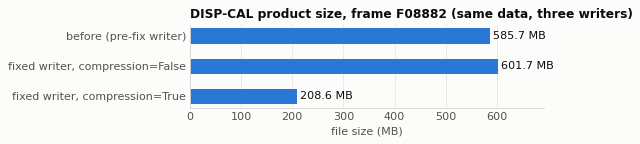

In [10]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.dpi": 80, "savefig.dpi": 80, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#d9d8d2", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

fig, ax = plt.subplots(figsize=(7, 1.9))
labels = list(files)[::-1]
values = sizes["file size MB"].iloc[:3].to_numpy()[::-1]
bars = ax.barh(labels, values, height=0.5, color=BLUE)
for bar, v in zip(bars, values):
    ax.text(v + values.max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{v:,.1f} MB", va="center", color=INK)
ax.set_xlim(0, values.max() * 1.15)
ax.set_xlabel("file size (MB)")
ax.set_title("DISP-CAL product size, frame F08882 (same data, three writers)")
ax.xaxis.grid(True, color="#e8e7e1", linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(length=0)
fig.tight_layout()
plt.show()

## 4. Reading a 512×512 window

Two costs of a window read:

* **wall time** with h5py (median over 20 windows at the same random positions in each
  file; each layer is read once beforehand so the three files are treated alike). The
  files are on a shared filesystem, so these timings include I/O, vary from run to run
  and are only indicative;
* **bytes that have to be fetched** — what matters for a product served from object
  storage. A contiguous dataset has no chunk index: the window is either one byte range
  spanning 512 full-width rows, or 512 separate small ranges. A chunked dataset needs only
  the (compressed) chunks the window touches.

In [11]:
WINDOW, N_WINDOWS = 512, 20
with h5py.File(BEFORE_NC) as f:
    _, ny, nx = f["calibration"].shape
rng = np.random.default_rng(0)
corners = [(int(rng.integers(0, ny - WINDOW)), int(rng.integers(0, nx - WINDOW))) for _ in range(N_WINDOWS)]


def window_cost(path):
    times, fetch_bytes, n_ranges = [], [], []
    with h5py.File(path) as f:
        d = f["calibration"]
        d[...]  # one untimed read first, the same for every file
        for r, c in corners:
            t0 = time.perf_counter()
            d[0, r : r + WINDOW, c : c + WINDOW]
            times.append(time.perf_counter() - t0)
            if d.chunks:
                _, cy, cx = d.chunks
                touched = [
                    d.id.get_chunk_info_by_coord((0, i * cy, j * cx)).size
                    for i in range(r // cy, (r + WINDOW - 1) // cy + 1)
                    for j in range(c // cx, (c + WINDOW - 1) // cx + 1)
                ]
                fetch_bytes.append(sum(touched))
                n_ranges.append(len(touched))
            else:  # one range from the first to the last pixel of the window
                fetch_bytes.append(((WINDOW - 1) * nx + WINDOW) * d.dtype.itemsize)
                n_ranges.append(1)
        t0 = time.perf_counter()
        d[...]
        t_full = time.perf_counter() - t0
    return {
        "window read ms (median)": round(float(np.median(times)) * 1e3, 2),
        "bytes to fetch per window, MB (mean)": round(float(np.mean(fetch_bytes)) / 1e6, 2),
        "byte ranges per window (mean)": round(float(np.mean(n_ranges)), 1),
        "full layer read s": round(t_full, 2),
    }


window_table = pd.DataFrame({k: window_cost(p) for k, p in files.items()}).T
window_table

,window read ms (median),"bytes to fetch per window, MB (mean)",byte ranges per window (mean),full layer read s
before (pre-fix writer),4.01,19.35,1.0,0.45
"fixed writer, compression=False",0.57,2.36,9.0,0.43
"fixed writer, compression=True",7.81,0.83,9.0,1.28


In [12]:
b, z = window_table.iloc[0], window_table.iloc[2]
print(
    f"A 512x512 window (1.05 MB of float32) needs {b.iloc[1]:.1f} MB from the contiguous pre-fix file "
    f"in one range (or {WINDOW} ranges of {WINDOW * 4 / 1e3:.1f} kB), and {z.iloc[1]:.2f} MB in "
    f"{z.iloc[2]:.0f} chunk ranges from the fixed product: {b.iloc[1] / z.iloc[1]:.0f}x fewer bytes."
)
print(
    f"Measured wall time per window: {b.iloc[0]} ms (contiguous) vs {z.iloc[0]} ms (gzip chunks); "
    f"full layer: {b.iloc[3]} s vs {z.iloc[3]} s (indicative: shared filesystem). "
    "Decompression costs some CPU time; the saving is in bytes stored and transferred."
)

A 512x512 window (1.05 MB of float32) needs 19.4 MB from the contiguous pre-fix file in one range (or 512 ranges of 2.0 kB), and 0.83 MB in 9 chunk ranges from the fixed product: 23x fewer bytes.
Measured wall time per window: 4.01 ms (contiguous) vs 7.81 ms (gzip chunks); full layer: 0.45 s vs 1.28 s (indicative: shared filesystem). Decompression costs some CPU time; the saving is in bytes stored and transferred.


## 5. The data is unchanged

In [13]:
def same_bits(a, b):
    return a.dtype == b.dtype and a.shape == b.shape and a.tobytes() == b.tobytes()


checks = {}
for label, path in files.items():
    with xr.open_dataset(path, engine="h5netcdf") as ds:
        for name in ("calibration", "calibration_std"):
            checks[(label, f"/{name}")] = same_bits(ds[name].values, layers[name])
    with xr.open_dataset(path, group="auxiliary", engine="h5netcdf") as ds:
        for k, v in aux.items():
            checks[(label, f"/auxiliary/{k}")] = same_bits(ds[k].values, v)

result = pd.Series(checks, name="bit-identical to golden").unstack(0)[list(files)]
assert result.to_numpy().all()
n_nan = int(np.isnan(layers["calibration"]).sum())
print(f"NaN pixels in /calibration: {n_nan:,} of {layers['calibration'].size:,} (preserved)")
result

NaN pixels in /calibration: 24,789,047 of 73,185,112 (preserved)


,before (pre-fix writer),"fixed writer, compression=False","fixed writer, compression=True"
/auxiliary/east_west,True,True,True
/auxiliary/north_south,True,True,True
/auxiliary/up_down,True,True,True
/calibration,True,True,True
/calibration_std,True,True,True


## Summary

* Before (pre-fix writer, `d0901b3`): `/calibration` and `/calibration_std` contiguous and
  unfiltered, 292.7 MB each.
* After: `(1, 256, 256)` chunks, gzip-4 + shuffle, `float32`, `_FillValue = NaN`; the
  table in section 3 gives the resulting file size, section 4 the bytes a window read needs
  and the read times measured here.
* `compression=False` (runconfig `output_options.compression: false`) keeps the chunking
  and writes no filters.
* All layers of all three files are bit-identical to the golden arrays, NaNs included.